<a href="https://colab.research.google.com/github/saisudhanv/ML-Practice/blob/main/Outlier_detection_using_IQR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df = pd.read_csv('/content/placement (1).csv')

In [13]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [14]:
df.sample(5)

,cgpa,placement_exam_marks,placed
257,5.74,76.0,0
705,6.55,35.0,1
516,6.83,28.0,0
585,7.85,49.0,1
153,6.29,10.0,1


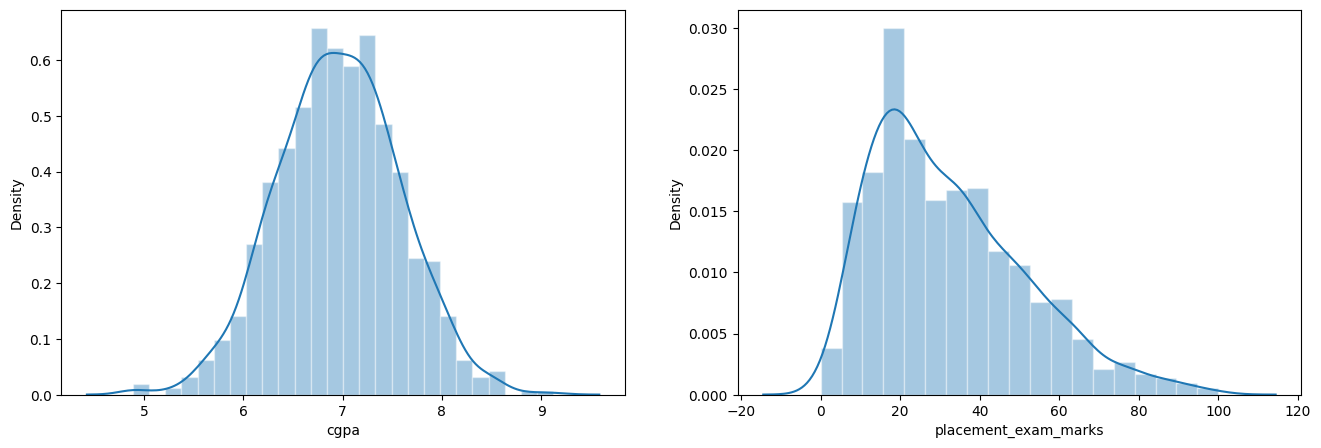

In [21]:
plt.figure(figsize=(16,5)) # This is the syntax used to get a similar o/p like distplot
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True, stat='density', kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True, stat='density', kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))

plt.show()

In [22]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: ylabel='placement_exam_marks'>

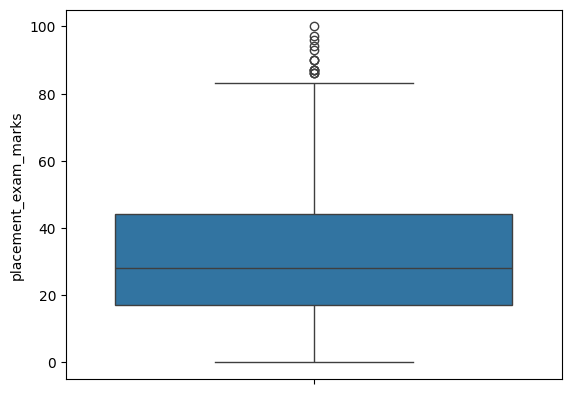

In [23]:
sns.boxplot(df['placement_exam_marks'])

In [24]:
# Finding IQR
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)

In [27]:
Q1

np.float64(17.0)

In [28]:
Q3

np.float64(44.0)

In [25]:
IQR = Q3 - Q1

In [26]:
IQR

np.float64(27.0)

In [29]:
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

In [30]:
upper_limit

np.float64(84.5)

In [31]:
lower_limit

np.float64(-23.5)

**FInding Outliers**

In [32]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [34]:
df[df['placement_exam_marks'] < lower_limit] # There will be no outliers becoz, the minimum value is 0

,cgpa,placement_exam_marks,placed


**Trimming**

In [36]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [37]:
new_df.shape

(985, 3)

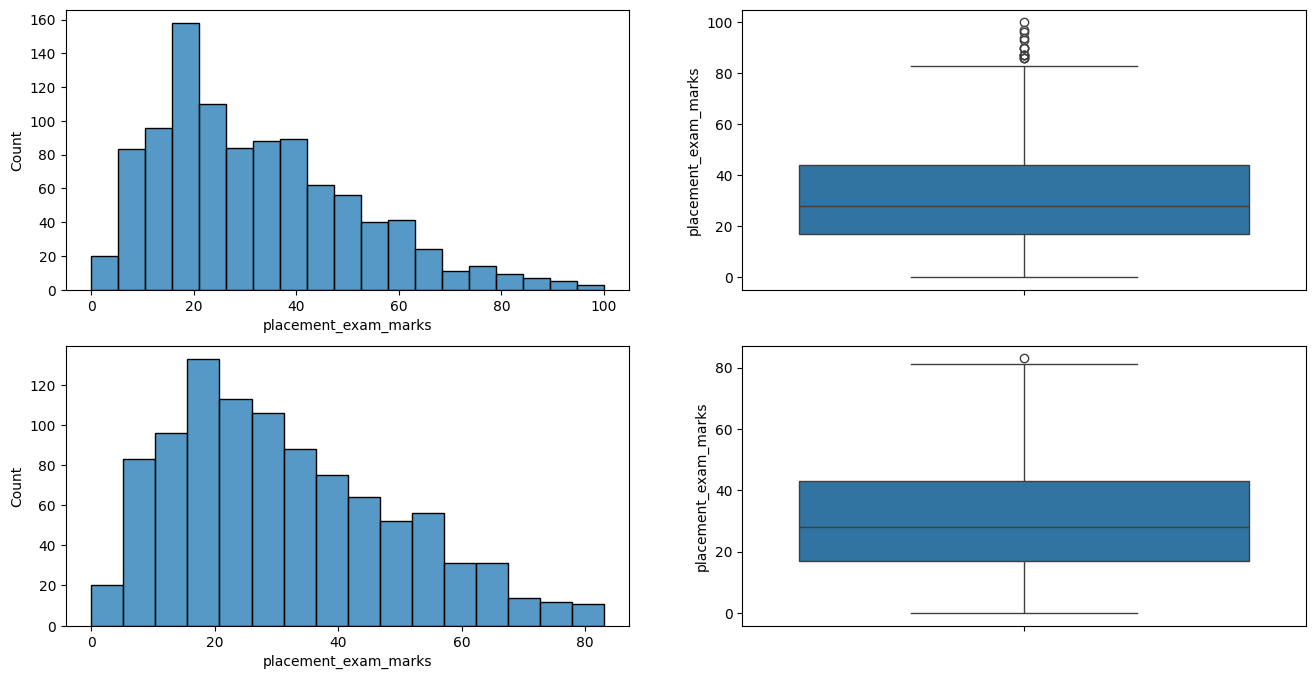

In [39]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()

Recalculated IQR because still there one outlier, therefore performed trimming once again

In [40]:
# Recalculate IQR for new_df
Q1_new = new_df['placement_exam_marks'].quantile(0.25)
Q3_new = new_df['placement_exam_marks'].quantile(0.75)
IQR_new = Q3_new - Q1_new

upper_limit_new = Q3_new + 1.5 * IQR_new
lower_limit_new = Q1_new - 1.5 * IQR_new

# Filter new_df to create an even cleaner dataframe
clean_df = new_df[(new_df['placement_exam_marks'] >= lower_limit_new) & (new_df['placement_exam_marks'] <= upper_limit_new)]

print(f"Original df shape: {df.shape}")
print(f"new_df shape (after first trim): {new_df.shape}")
print(f"clean_df shape (after second trim): {clean_df.shape}")

Original df shape: (1000, 3)
new_df shape (after first trim): (985, 3)
clean_df shape (after second trim): (984, 3)


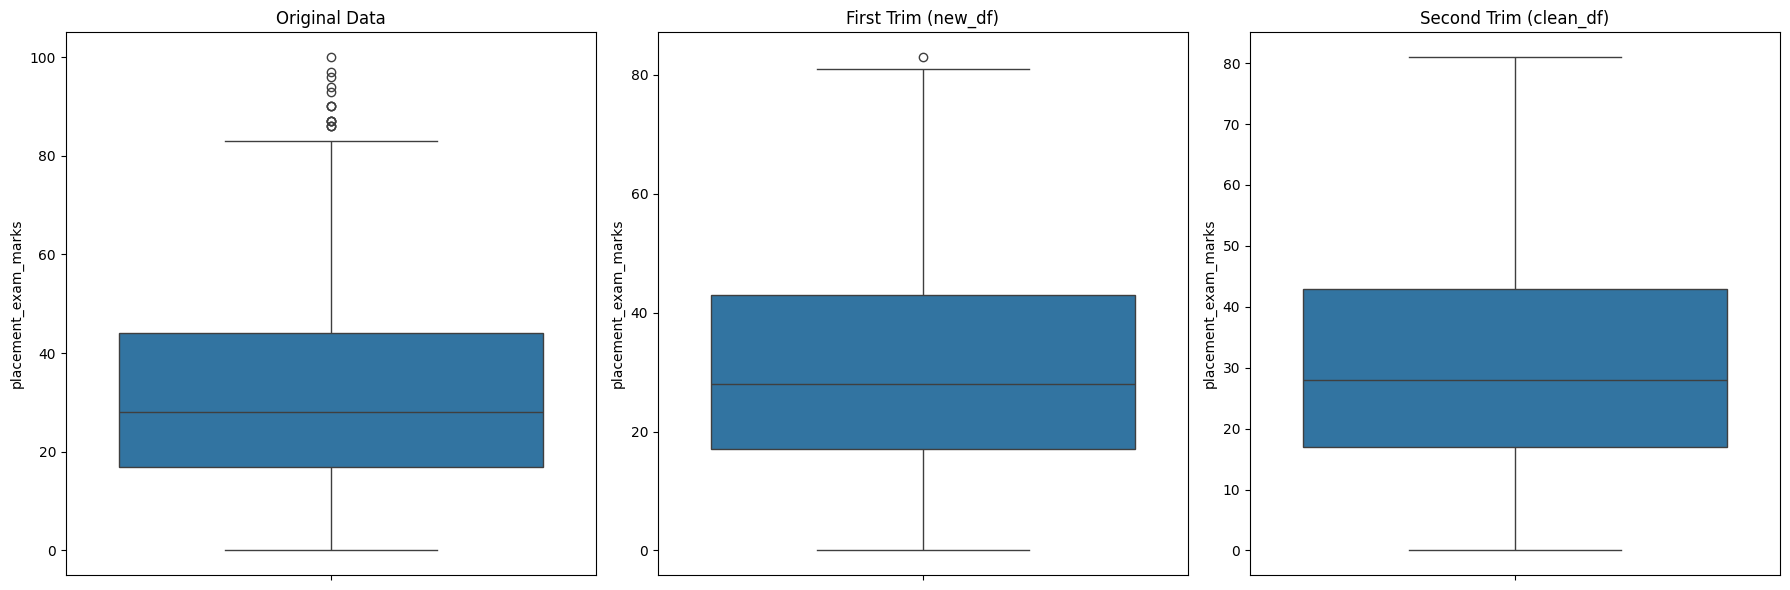

In [41]:
# Compare distributions and boxplots of original, first trimmed, and second trimmed data
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['placement_exam_marks'])
plt.title('Original Data')

plt.subplot(1, 3, 2)
sns.boxplot(y=new_df['placement_exam_marks'])
plt.title('First Trim (new_df)')

plt.subplot(1, 3, 3)
sns.boxplot(y=clean_df['placement_exam_marks'])
plt.title('Second Trim (clean_df)')

plt.tight_layout()
plt.show()

**Capping**

In [44]:
new_df_cap = df.copy()
# The syntax of np.where(condition, true -> then what to do, false -> then what to do)
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [45]:
new_df_cap.shape

(1000, 3)

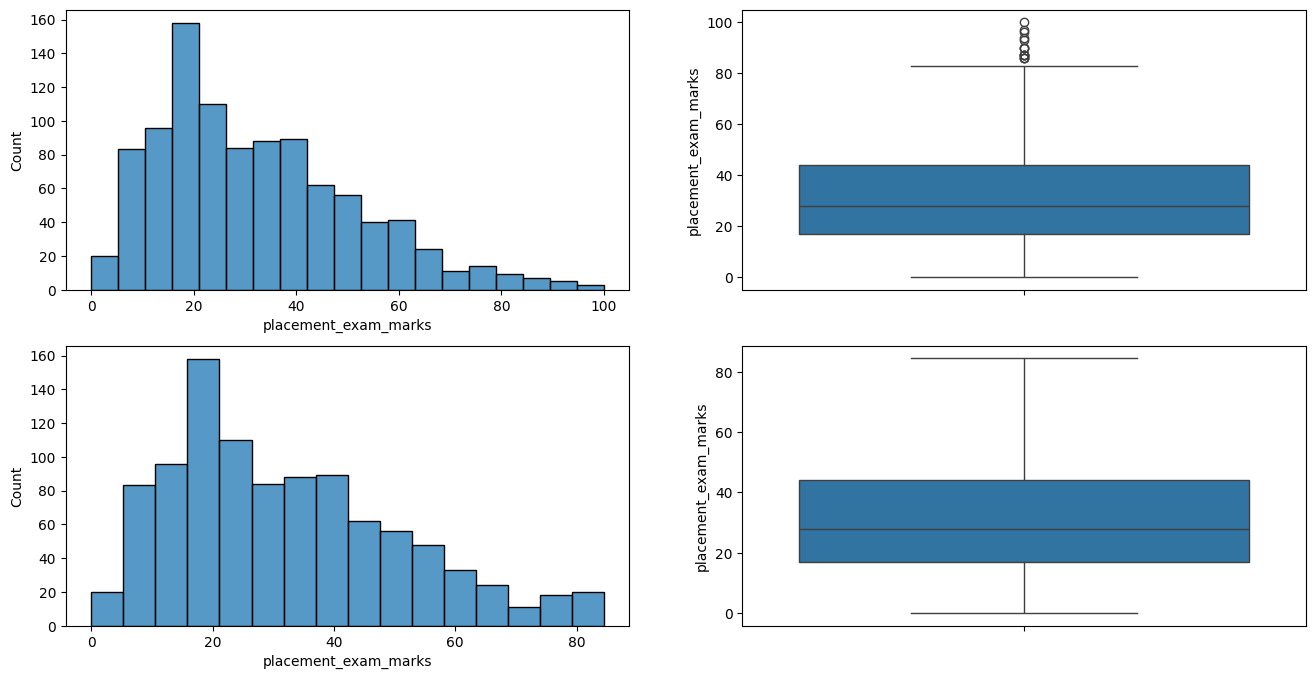

In [46]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()